# Algorithmic Trading Project

This notebook downloads 1-hour OHLCV data from Binance for `BTCUSDT`, `ETHUSDT`, and an optional altcoin (`DOGEUSDT` by default), stores the raw market data in Parquet, audits data quality, constructs excess simple returns using the previous-step risk-free rate, flags return outliers with a rolling z-score filter, and displays the flagged rows without altering the original candles.

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path
from datetime import datetime, timezone
from IPython.display import display
import ccxt
from dotenv import load_dotenv
load_dotenv()

True

In [84]:
SYMBOLS    = ["BTC/USDT", "ETH/USDT", "DOGE/USDT", "SOL/USDT"]
TIMEFRAME  = "1h"
SINCE      = "2024-06-01"
DATA_DIR   = Path("data")

In [85]:
exchange = ccxt.binance()
since_ms = exchange.parse8601(f"{SINCE}T00:00:00Z")


def write_parquet_safe(df: pd.DataFrame, path: Path) -> None:
    import pyarrow as pa
    import pyarrow.parquet as pq

    # Ensure destination folder exists before writing parquet.
    path.parent.mkdir(parents=True, exist_ok=True)

    # Bypass pandas' parquet wrapper, which can trip over Arrow extension
    # registration when notebook cells are re-run in the same kernel.
    table = pa.Table.from_pandas(df, preserve_index=True)
    pq.write_table(table, path)


for symbol in SYMBOLS:
    print(f"Downloading {symbol}...", end="", flush=True)

    all_bars = []
    since    = since_ms

    while True:
        bars = exchange.fetch_ohlcv(symbol, timeframe=TIMEFRAME,
                                    since=since, limit=1000)
        if not bars:
            break
        all_bars.extend(bars)
        since = bars[-1][0] + 1
        print(".", end="", flush=True)
        time.sleep(0.3)

        now_ms = datetime.now(timezone.utc).timestamp() * 1000
        if bars[-1][0] >= now_ms - 3_600_000:
            break

    df = pd.DataFrame(all_bars,
                      columns=["timestamp", "open", "high", "low",
                                "close", "volume"])
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
    df = df.set_index("timestamp").sort_index()

    fname = DATA_DIR / f"{symbol.replace('/', '')}_1h.parquet"
    write_parquet_safe(df, fname)
    print(f" {len(df):,} bars → {fname}")

print("\nDone.")


Done.


### Macro Data — Effective Fed Funds Rate (FRED)

In [86]:
import os
from fredapi import Fred

# Set FRED_API_KEY in your environment before running this cell.
fred = Fred(api_key=os.environ["FRED_API_KEY"])

dff = fred.get_series("DFF", observation_start=SINCE)
dff = dff.rename("fed_funds_rate").rename_axis("date")
dff.index = pd.to_datetime(dff.index, utc=True)

dff_path = DATA_DIR / "DFF_daily.parquet"
dff.to_frame().to_parquet(dff_path, engine="pyarrow")
print(f"Fed Funds Rate: {len(dff):,} observations → {dff_path}")
dff.tail()

Fed Funds Rate: 655 observations → data/DFF_daily.parquet


date
2026-03-13 00:00:00+00:00    3.64
2026-03-14 00:00:00+00:00    3.64
2026-03-15 00:00:00+00:00    3.64
2026-03-16 00:00:00+00:00    3.64
2026-03-17 00:00:00+00:00    3.64
Name: fed_funds_rate, dtype: float64

### Data Cleaning

In [87]:
PROCESSED_DIR = DATA_DIR / "processed" / "binance"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

VALUE_COLUMNS = ["open", "high", "low", "close", "volume"]
RF_PATH = DATA_DIR / "DFF_daily.parquet"
HOURS_PER_YEAR = 24 * 365


def read_parquet_safe(path: Path) -> pd.DataFrame:
    import pyarrow.parquet as pq

    table = pq.read_table(path)
    return table.to_pandas()


def load_hourly_risk_free_rate(path: Path) -> pd.Series:
    rf_frame = read_parquet_safe(path)

    if isinstance(rf_frame, pd.Series):
        rf_series = rf_frame.rename("fed_funds_rate")
    elif "fed_funds_rate" in rf_frame.columns:
        rf_series = rf_frame["fed_funds_rate"]
    elif rf_frame.shape[1] == 1:
        rf_series = rf_frame.iloc[:, 0].rename("fed_funds_rate")
    else:
        raise ValueError(f"Could not identify the risk-free column in {path}")

    rf_index = pd.DatetimeIndex(rf_series.index)
    if rf_index.tz is None:
        rf_index = rf_index.tz_localize("UTC")
    else:
        rf_index = rf_index.tz_convert("UTC")

    rf_series.index = rf_index
    rf_series = rf_series.sort_index().astype(float)

    # DFF is quoted in annualized percent, so convert it to an hourly simple rate.
    return ((1.0 + rf_series.div(100.0)).pow(1.0 / HOURS_PER_YEAR) - 1.0).rename("risk_free_rate")


def audit_ohlcv(df: pd.DataFrame, symbol: str, stage: str) -> dict:
    audit_frame = df.sort_index().copy()
    index = pd.DatetimeIndex(audit_frame.index)

    if index.tz is None:
        index = index.tz_localize("UTC")
    else:
        index = index.tz_convert("UTC")

    audit_frame.index = index
    expected_index = pd.date_range(index.min(), index.max(), freq=TIMEFRAME, tz="UTC")
    gap_hours = index.to_series().diff().dropna().div(pd.Timedelta(hours=1))

    high_low_violations = (audit_frame["high"] < audit_frame["low"]).fillna(False)
    candle_rule_violations = (
        (audit_frame["high"] < audit_frame[["open", "close"]].max(axis=1))
        | (audit_frame["low"] > audit_frame[["open", "close"]].min(axis=1))
    ).fillna(False)

    return {
        "symbol": symbol,
        "stage": stage,
        "rows": len(audit_frame),
        "start": index.min(),
        "end": index.max(),
        "duplicate_timestamps": int(index.duplicated().sum()),
        "missing_bars": int(len(expected_index.difference(index))),
        "null_rows": int(audit_frame[VALUE_COLUMNS].isna().any(axis=1).sum()),
        "null_values": int(audit_frame[VALUE_COLUMNS].isna().sum().sum()),
        "non_positive_price_rows": int((audit_frame[["open", "high", "low", "close"]] <= 0).any(axis=1).sum()),
        "negative_volume_rows": int((audit_frame["volume"] < 0).sum()),
        "zero_volume_rows": int((audit_frame["volume"] == 0).sum()),
        "high_below_low_rows": int(high_low_violations.sum()),
        "candle_rule_violations": int(candle_rule_violations.sum()),
        "max_gap_hours": float(gap_hours.max()) if not gap_hours.empty else 0.0,
        "outliers_flagged": int(audit_frame["is_outlier"].sum()) if "is_outlier" in audit_frame else 0,
        "missing_bar_rows": int(audit_frame["missing_bar"].sum()) if "missing_bar" in audit_frame else 0,
    }


def flag_ohlcv_outliers(
    df: pd.DataFrame,
    risk_free_rate: pd.Series,
    rolling_window: int = 72,
    zscore_threshold: float = 5.0,
) -> pd.DataFrame:
    flagged = df.sort_index().copy()
    flagged.index = pd.DatetimeIndex(flagged.index)

    if flagged.index.tz is None:
        flagged.index = flagged.index.tz_localize("UTC")
    else:
        flagged.index = flagged.index.tz_convert("UTC")

    flagged.index.name = "timestamp"
    flagged["missing_bar"] = False
    flagged["simple_return"] = flagged["close"].pct_change()

    aligned_rf = risk_free_rate.reindex(flagged.index, method="ffill")
    flagged["risk_free_rate"] = aligned_rf.shift(1)
    flagged["excess_simple_return"] = flagged["simple_return"] - flagged["risk_free_rate"]

    min_periods = max(rolling_window // 3, 12)
    rolling_returns = flagged["excess_simple_return"].rolling(window=rolling_window, min_periods=min_periods)
    rolling_std = rolling_returns.std(ddof=0).replace(0.0, np.nan)
    flagged["return_zscore"] = (flagged["excess_simple_return"] - rolling_returns.mean()) / rolling_std
    flagged["is_outlier"] = flagged["return_zscore"].abs().gt(zscore_threshold).fillna(False)
    flagged["clean_return"] = flagged["excess_simple_return"]
    return flagged


risk_free_rate = load_hourly_risk_free_rate(RF_PATH)

flagged_frames = {}
quality_rows = []
flagged_rows = []

for symbol in SYMBOLS:
    raw_path = DATA_DIR / f"{symbol.replace('/', '')}_{TIMEFRAME}.parquet"
    raw_df = read_parquet_safe(raw_path)
    raw_df.index = pd.DatetimeIndex(raw_df.index)

    quality_rows.append(audit_ohlcv(raw_df, symbol, "raw"))

    flagged_df = flag_ohlcv_outliers(raw_df, risk_free_rate=risk_free_rate)
    flagged_path = PROCESSED_DIR / f"{symbol.replace('/', '')}_{TIMEFRAME}_flagged.parquet"
    write_parquet_safe(flagged_df, flagged_path)

    flagged_frames[symbol] = flagged_df
    quality_rows.append(audit_ohlcv(flagged_df, symbol, "flagged"))

    symbol_flags = flagged_df.loc[
        flagged_df["is_outlier"],
        [
            "open",
            "high",
            "low",
            "close",
            "volume",
            "simple_return",
            "risk_free_rate",
            "excess_simple_return",
            "return_zscore",
        ],
    ].copy()
    symbol_flags.insert(0, "symbol", symbol)
    flagged_rows.append(symbol_flags.reset_index())

quality_report = pd.DataFrame(quality_rows).sort_values(["symbol", "stage"]).reset_index(drop=True)
display(quality_report)

post_clean_checks = quality_report.loc[
    quality_report["stage"] == "flagged",
    [
        "symbol",
        "missing_bars",
        "null_rows",
        "non_positive_price_rows",
        "negative_volume_rows",
        "high_below_low_rows",
        "candle_rule_violations",
        "outliers_flagged",
    ],
]
display(post_clean_checks)

flagged_outliers = pd.concat(flagged_rows, ignore_index=True).sort_values(["symbol", "timestamp"])
display(flagged_outliers)


,symbol,stage,rows,start,end,duplicate_timestamps,missing_bars,null_rows,null_values,non_positive_price_rows,negative_volume_rows,zero_volume_rows,high_below_low_rows,candle_rule_violations,max_gap_hours,outliers_flagged,missing_bar_rows
0,BTC/USDT,flagged,15762,2024-06-01 00:00:00+00:00,2026-03-19 17:00:00+00:00,0,0,0,0,0,0,0,0,0,1.0,27,0
1,BTC/USDT,raw,15762,2024-06-01 00:00:00+00:00,2026-03-19 17:00:00+00:00,0,0,0,0,0,0,0,0,0,1.0,0,0
2,DOGE/USDT,flagged,15762,2024-06-01 00:00:00+00:00,2026-03-19 17:00:00+00:00,0,0,0,0,0,0,0,0,0,1.0,27,0
3,DOGE/USDT,raw,15762,2024-06-01 00:00:00+00:00,2026-03-19 17:00:00+00:00,0,0,0,0,0,0,0,0,0,1.0,0,0
4,ETH/USDT,flagged,15762,2024-06-01 00:00:00+00:00,2026-03-19 17:00:00+00:00,0,0,0,0,0,0,0,0,0,1.0,37,0
5,ETH/USDT,raw,15762,2024-06-01 00:00:00+00:00,2026-03-19 17:00:00+00:00,0,0,0,0,0,0,0,0,0,1.0,0,0
6,SOL/USDT,flagged,15762,2024-06-01 00:00:00+00:00,2026-03-19 17:00:00+00:00,0,0,0,0,0,0,0,0,0,1.0,23,0
7,SOL/USDT,raw,15762,2024-06-01 00:00:00+00:00,2026-03-19 17:00:00+00:00,0,0,0,0,0,0,0,0,0,1.0,0,0


,symbol,missing_bars,null_rows,non_positive_price_rows,negative_volume_rows,high_below_low_rows,candle_rule_violations,outliers_flagged
0,BTC/USDT,0,0,0,0,0,0,27
2,DOGE/USDT,0,0,0,0,0,0,27
4,ETH/USDT,0,0,0,0,0,0,37
6,SOL/USDT,0,0,0,0,0,0,23


,timestamp,symbol,open,high,low,close,volume,simple_return,risk_free_rate,excess_simple_return,return_zscore
0,2024-06-12 12:00:00+00:00,BTC/USDT,67778.43,69488.00,67736.00,69339.29,5379.40042,0.023029,0.000006,0.023023,5.684964
1,2024-06-24 09:00:00+00:00,BTC/USDT,62730.92,62867.00,60567.01,61402.28,6567.42005,-0.021180,0.000006,-0.021186,-5.529886
2,2024-07-04 01:00:00+00:00,BTC/USDT,60430.01,60498.19,58444.00,58561.10,5938.30437,-0.030927,0.000006,-0.030933,-5.732817
3,2024-07-08 08:00:00+00:00,BTC/USDT,55852.00,57891.81,55741.11,57792.00,4740.11500,0.034734,0.000006,0.034729,5.115356
4,2024-08-12 14:00:00+00:00,BTC/USDT,58157.55,60711.09,57800.00,60299.98,5156.24546,0.036838,0.000006,0.036832,5.208797
...,...,...,...,...,...,...,...,...,...,...,...
109,2025-12-01 00:00:00+00:00,SOL/USDT,133.48,133.74,127.53,127.57,958104.52600,-0.044276,0.000004,-0.044281,-5.104471
110,2025-12-15 15:00:00+00:00,SOL/USDT,130.48,130.60,126.45,126.89,713478.62400,-0.027588,0.000004,-0.027592,-5.150818
111,2026-01-18 23:00:00+00:00,SOL/USDT,142.86,142.86,137.74,137.87,407539.60100,-0.034929,0.000004,-0.034933,-6.468612
112,2026-01-25 19:00:00+00:00,SOL/USDT,121.69,121.87,117.15,117.96,959971.67700,-0.030652,0.000004,-0.030656,-5.205040


### Excess Return Time Series

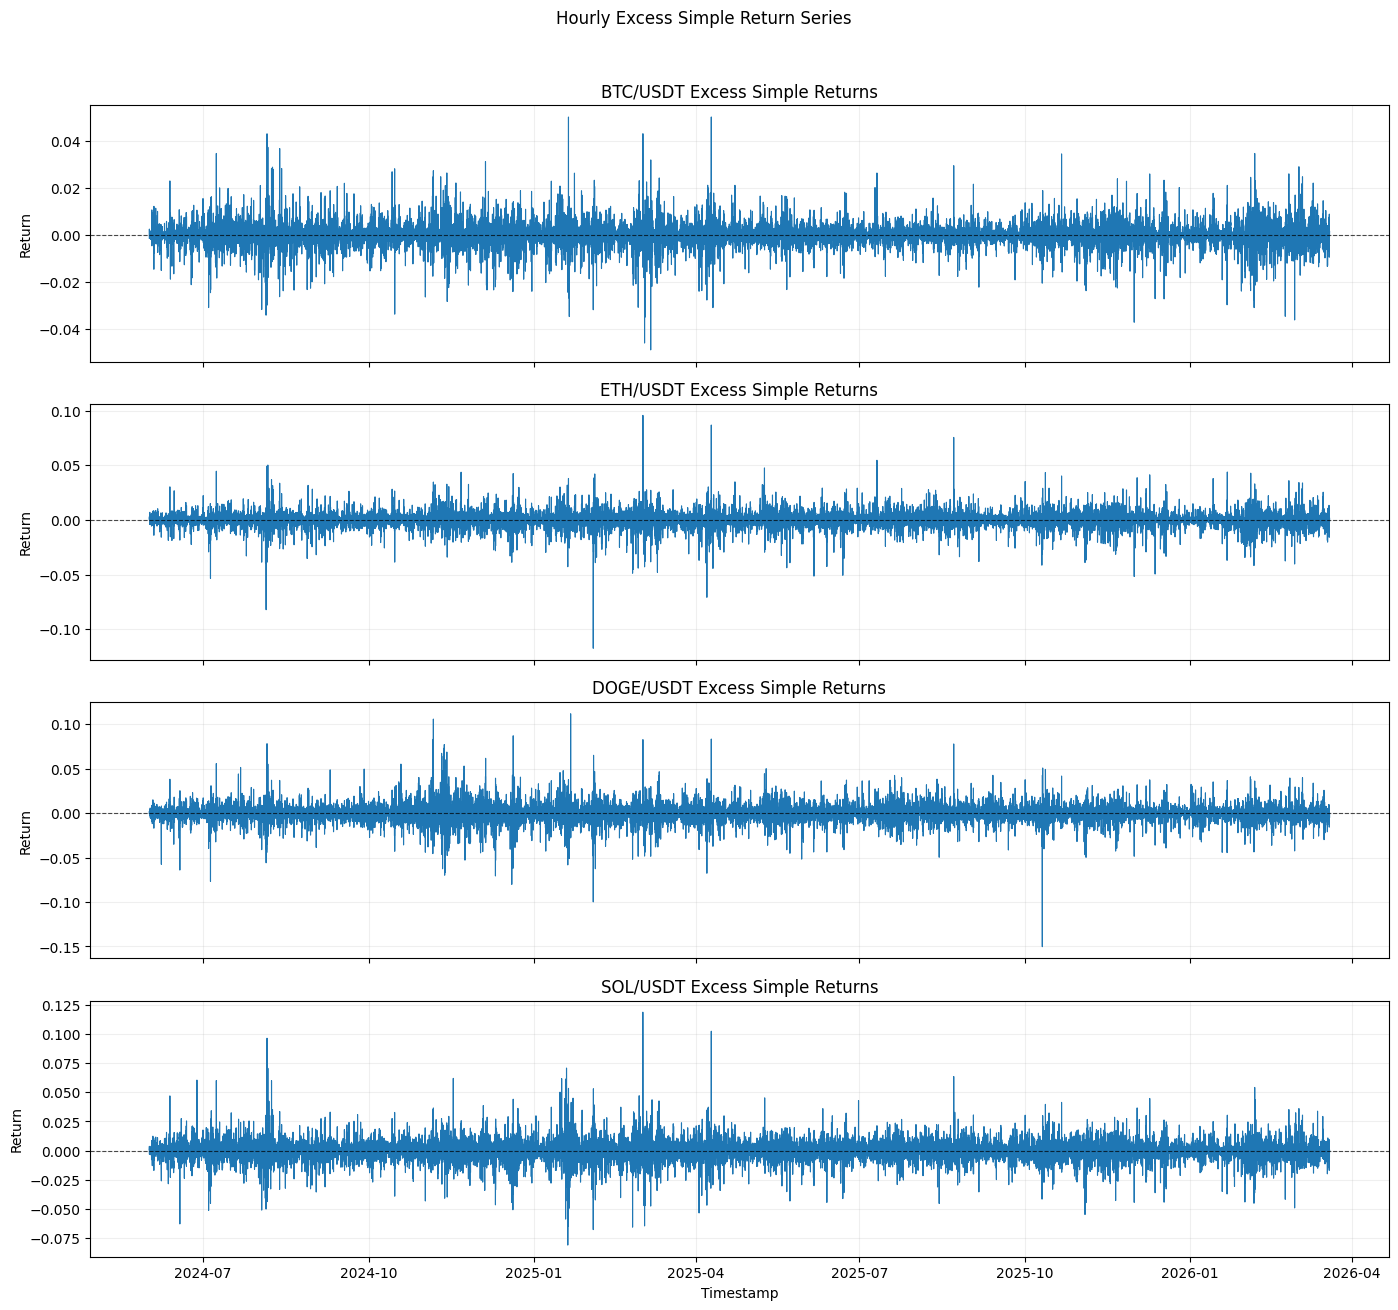

In [88]:
fig, axes = plt.subplots(len(SYMBOLS), 1, figsize=(14, 3.2 * len(SYMBOLS)), sharex=True)

if len(SYMBOLS) == 1:
    axes = [axes]

for ax, symbol in zip(axes, SYMBOLS):
    plot_frame = flagged_frames[symbol]
    ax.plot(plot_frame.index, plot_frame["excess_simple_return"], lw=0.8, color="tab:blue")
    ax.axhline(0.0, color="black", lw=0.8, ls="--", alpha=0.7)
    ax.set_title(f"{symbol} Excess Simple Returns")
    ax.set_ylabel("Return")
    ax.grid(alpha=0.2)

axes[-1].set_xlabel("Timestamp")
fig.suptitle("Hourly Excess Simple Return Series", y=1.02)
fig.tight_layout()
plt.show()


## Pair Diagnostics: Cointegration Tests (All Pairs)

In [89]:
from itertools import combinations
from statsmodels.tsa.vector_ar.vecm import coint_johansen


def infer_rank_95(test_stats: np.ndarray, critical_values_95: np.ndarray) -> int:
    rejections = list(test_stats > critical_values_95)

    if rejections[0] and not rejections[1]:
        return 1
    if not rejections[0]:
        return 0
    return 2


def interpret_pair_result(trace_rank_95: int, maxeig_rank_95: int) -> str:
    if trace_rank_95 == 1 and maxeig_rank_95 == 1:
        return (
            "Confirmed rank-1 cointegration. Both Johansen tests support one stationary "
            "spread, which is the standard setup for pairs trading."
        )
    if trace_rank_95 == 0 and maxeig_rank_95 == 0:
        return (
            "No cointegration evidence at 95%. The data do not support a mean-reverting "
            "spread for this pair under the current specification."
        )
    if trace_rank_95 != maxeig_rank_95:
        return (
            "Mixed evidence. The trace and max-eigenvalue tests disagree, so this pair "
            "should be treated as inconclusive rather than tradable."
        )
    return (
        "Non-standard outcome. Rank 2 in a two-asset system suggests the prices may be "
        "stationary already or the model specification is not appropriate for pairs trading."
    )


pair_results = {}
summary_rows = []

for left_symbol, right_symbol in combinations(SYMBOLS, 2):
    pair_name = f"{left_symbol} vs {right_symbol}"
    pair_prices = pd.concat(
        [
            flagged_frames[left_symbol]["close"].rename(left_symbol),
            flagged_frames[right_symbol]["close"].rename(right_symbol),
        ],
        axis=1,
    ).dropna()

    log_prices = np.log(pair_prices)
    johansen_result = coint_johansen(log_prices, det_order=0, k_ar_diff=1)

    trace_table = pd.DataFrame(
        {
            "rank_null": [f"r <= {i}" for i in range(log_prices.shape[1])],
            "trace_stat": johansen_result.lr1,
            "crit_95": johansen_result.cvt[:, 1],
        }
    )
    trace_table["reject_95"] = trace_table["trace_stat"] > trace_table["crit_95"]

    maxeig_table = pd.DataFrame(
        {
            "rank_null": [f"r = {i}" for i in range(log_prices.shape[1])],
            "maxeig_stat": johansen_result.lr2,
            "crit_95": johansen_result.cvm[:, 1],
        }
    )
    maxeig_table["reject_95"] = maxeig_table["maxeig_stat"] > maxeig_table["crit_95"]

    trace_rank_95 = infer_rank_95(johansen_result.lr1, johansen_result.cvt[:, 1])
    maxeig_rank_95 = infer_rank_95(johansen_result.lr2, johansen_result.cvm[:, 1])
    cointegration_confirmed_95 = trace_rank_95 == 1 and maxeig_rank_95 == 1
    interpretation = interpret_pair_result(trace_rank_95, maxeig_rank_95)

    pair_results[pair_name] = {
        "prices": pair_prices,
        "log_prices": log_prices,
        "trace_table": trace_table,
        "maxeig_table": maxeig_table,
        "trace_rank_95": trace_rank_95,
        "maxeig_rank_95": maxeig_rank_95,
        "cointegration_confirmed_95": cointegration_confirmed_95,
        "interpretation": interpretation,
    }

    summary_rows.append(
        {
            "pair": pair_name,
            "observations": len(log_prices),
            "trace_rank_95": trace_rank_95,
            "maxeig_rank_95": maxeig_rank_95,
            "cointegration_confirmed_95": cointegration_confirmed_95,
            "interpretation": interpretation,
        }
    )

    print("=" * 100)
    print(pair_name)
    print("Assumptions: det_order=0, k_ar_diff=1")
    print(f"Observations used: {len(log_prices):,}")
    print("Trace test at 95%:")
    display(trace_table)
    print("Max-eigenvalue test at 95%:")
    display(maxeig_table)
    print(f"Inferred rank at 95% -> trace: {trace_rank_95}, max-eigenvalue: {maxeig_rank_95}")
    print(f"Interpretation: {interpretation}")
    print()

summary_df = pd.DataFrame(summary_rows).sort_values(
    ["cointegration_confirmed_95", "pair"],
    ascending=[False, True],
).reset_index(drop=True)

print("Summary across all pairs at the 95% level:")
display(summary_df)

confirmed_pairs = summary_df.loc[summary_df["cointegration_confirmed_95"], "pair"].tolist()
mixed_pairs = summary_df.loc[
    summary_df["trace_rank_95"] != summary_df["maxeig_rank_95"],
    "pair",
].tolist()

print("Portfolio-level interpretation:")
if confirmed_pairs:
    print(
        "Confirmed rank-1 candidates at 95%: "
        + ", ".join(confirmed_pairs)
        + ". These are the strongest pairs to carry forward into hedge-ratio and spread tests."
    )
else:
    print("No pair shows joint trace/max-eigenvalue support for rank-1 cointegration at 95%.")

if mixed_pairs:
    print(
        "Mixed-evidence pairs: "
        + ", ".join(mixed_pairs)
        + ". Treat these as inconclusive until the specification is rechecked."
    )

print(
    "For pairs trading, rank 1 is the useful case. Rank 0 means no stationary spread, "
    "while rank 2 is not the standard non-stationary price-pair setup."
)


BTC/USDT vs ETH/USDT
Assumptions: det_order=0, k_ar_diff=1
Observations used: 15,762
Trace test at 95%:


,rank_null,trace_stat,crit_95,reject_95
0,r <= 0,11.617304,15.4943,False
1,r <= 1,4.075686,3.8415,True


Max-eigenvalue test at 95%:


,rank_null,maxeig_stat,crit_95,reject_95
0,r = 0,7.541618,14.2639,False
1,r = 1,4.075686,3.8415,True


Inferred rank at 95% -> trace: 0, max-eigenvalue: 0
Interpretation: No cointegration evidence at 95%. The data do not support a mean-reverting spread for this pair under the current specification.

BTC/USDT vs DOGE/USDT
Assumptions: det_order=0, k_ar_diff=1
Observations used: 15,762
Trace test at 95%:


...

Max-eigenvalue test at 95%:


,rank_null,maxeig_stat,crit_95,reject_95
0,r = 0,5.881364,14.2639,False
1,r = 1,1.368077,3.8415,False


Inferred rank at 95% -> trace: 0, max-eigenvalue: 0
Interpretation: No cointegration evidence at 95%. The data do not support a mean-reverting spread for this pair under the current specification.

Summary across all pairs at the 95% level:


,pair,observations,trace_rank_95,maxeig_rank_95,cointegration_confirmed_95,interpretation
0,BTC/USDT vs DOGE/USDT,15762,0,0,False,No cointegration evidence at 95%. The data do ...
1,BTC/USDT vs ETH/USDT,15762,0,0,False,No cointegration evidence at 95%. The data do ...
2,BTC/USDT vs SOL/USDT,15762,0,0,False,No cointegration evidence at 95%. The data do ...
3,DOGE/USDT vs SOL/USDT,15762,0,0,False,No cointegration evidence at 95%. The data do ...
4,ETH/USDT vs DOGE/USDT,15762,0,0,False,No cointegration evidence at 95%. The data do ...
5,ETH/USDT vs SOL/USDT,15762,0,0,False,No cointegration evidence at 95%. The data do ...


Portfolio-level interpretation:
No pair shows joint trace/max-eigenvalue support for rank-1 cointegration at 95%.
For pairs trading, rank 1 is the useful case. Rank 0 means no stationary spread, while rank 2 is not the standard non-stationary price-pair setup.


## Strategy 1: Cross-Sectional Mean Reversion

We begin by aligning all four assets on a common hourly timestamp index and building a `close_df` panel with one close-price column per asset. From this panel we compute simple returns, a 24-bar rolling mean return for each asset, and cross-sectional z-scores at each timestamp.

In [90]:
ASSET_COLUMNS = SYMBOLS
ROLLING_MEAN_WINDOW = 24

close_df = pd.concat(
    [flagged_frames[symbol]["close"].rename(symbol) for symbol in ASSET_COLUMNS],
    axis=1,
).dropna()

return_df = close_df.pct_change()
rolling_mean_return_df = return_df.rolling(ROLLING_MEAN_WINDOW).mean()

cross_sectional_mean = rolling_mean_return_df.mean(axis=1)
cross_sectional_std = rolling_mean_return_df.std(axis=1, ddof=0).replace(0.0, np.nan)
zscore_df = rolling_mean_return_df.sub(cross_sectional_mean, axis=0).div(cross_sectional_std, axis=0)

display(close_df.tail())
display(zscore_df.tail())


,BTC/USDT,ETH/USDT,DOGE/USDT,SOL/USDT
timestamp,,,,
2026-03-19 13:00:00+00:00,69905.65,2137.49,0.09337,88.52
2026-03-19 14:00:00+00:00,69482.25,2121.68,0.09307,88.23
2026-03-19 15:00:00+00:00,69412.51,2118.81,0.09287,87.63
2026-03-19 16:00:00+00:00,69455.86,2115.09,0.09240,87.69
2026-03-19 17:00:00+00:00,69558.56,2117.98,0.09241,87.68


,BTC/USDT,ETH/USDT,DOGE/USDT,SOL/USDT
timestamp,,,,
2026-03-19 13:00:00+00:00,-0.120100,-1.553052,0.541713,1.131439
2026-03-19 14:00:00+00:00,-0.509187,-1.318522,0.506442,1.321266
2026-03-19 15:00:00+00:00,-0.782058,-1.159830,1.251758,0.690130
2026-03-19 16:00:00+00:00,-0.690144,-1.264870,0.897626,1.057389
2026-03-19 17:00:00+00:00,-0.035505,-1.575809,1.135353,0.475961


Signals are generated from lagged cross-sectional z-scores to avoid look-ahead bias. Assets with lagged z-score below -1 are candidates for the long basket, assets above +1 are candidates for the short basket, and the rest stay flat. We then balance the long and short sides so the portfolio is net-zero.

In [91]:
ENTRY_ZSCORE = 1.0
lagged_zscore_df = zscore_df.shift(1)

raw_signal_df = pd.DataFrame(0.0, index=close_df.index, columns=ASSET_COLUMNS)
raw_signal_df = raw_signal_df.mask(lagged_zscore_df < -ENTRY_ZSCORE, 1.0)
raw_signal_df = raw_signal_df.mask(lagged_zscore_df > ENTRY_ZSCORE, -1.0)


def balance_cross_sectional_signals(signal_row: pd.Series) -> pd.Series:
    balanced_row = pd.Series(0.0, index=signal_row.index)
    long_assets = signal_row[signal_row > 0].index
    short_assets = signal_row[signal_row < 0].index

    if len(long_assets) == 0 or len(short_assets) == 0:
        return balanced_row

    balanced_row.loc[long_assets] = 0.5 / len(long_assets)
    balanced_row.loc[short_assets] = -0.5 / len(short_assets)
    return balanced_row


signal_df = raw_signal_df.apply(balance_cross_sectional_signals, axis=1)

display(signal_df.tail())


,BTC/USDT,ETH/USDT,DOGE/USDT,SOL/USDT
timestamp,,,,
2026-03-19 13:00:00+00:00,0.0,0.5,0.0,-0.5
2026-03-19 14:00:00+00:00,0.0,0.5,0.0,-0.5
2026-03-19 15:00:00+00:00,0.0,0.5,0.0,-0.5
2026-03-19 16:00:00+00:00,0.0,0.5,-0.5,0.0
2026-03-19 17:00:00+00:00,0.0,0.5,0.0,-0.5


Position sizing uses lagged inverse-volatility weights from a 72-bar rolling volatility estimate. Within each side of the book, lower-volatility assets receive larger notional allocations. The long and short baskets are each scaled to 50% of gross exposure so the final portfolio remains market-neutral.

In [92]:
VOL_WINDOW = 72
INITIAL_CAPITAL_USDT = 10_000.0
GROSS_EXPOSURE_CAP_USDT = 100_000.0
TARGET_GROSS_EXPOSURE_USDT = GROSS_EXPOSURE_CAP_USDT

vol_df = return_df.rolling(VOL_WINDOW).std(ddof=0)
lagged_inv_vol_df = (1.0 / vol_df.replace(0.0, np.nan)).shift(1)


def build_inverse_vol_weights(signal_row: pd.Series, inv_vol_row: pd.Series) -> pd.Series:
    weight_row = pd.Series(0.0, index=signal_row.index)
    long_assets = signal_row[signal_row > 0].index
    short_assets = signal_row[signal_row < 0].index

    if len(long_assets) == 0 or len(short_assets) == 0:
        return weight_row

    long_inv_vol = inv_vol_row.loc[long_assets].dropna()
    short_inv_vol = inv_vol_row.loc[short_assets].dropna()

    if long_inv_vol.empty or short_inv_vol.empty:
        return weight_row

    weight_row.loc[long_inv_vol.index] = 0.5 * long_inv_vol / long_inv_vol.sum()
    weight_row.loc[short_inv_vol.index] = -0.5 * short_inv_vol / short_inv_vol.sum()
    return weight_row


position_weight_df = pd.DataFrame(
    [
        build_inverse_vol_weights(signal_df.loc[timestamp], lagged_inv_vol_df.loc[timestamp])
        for timestamp in close_df.index
    ],
    index=close_df.index,
)
position_weight_df.columns = ASSET_COLUMNS

theta_df = position_weight_df * TARGET_GROSS_EXPOSURE_USDT
gross_exposure_series = theta_df.abs().sum(axis=1)

assert (gross_exposure_series <= GROSS_EXPOSURE_CAP_USDT + 1e-9).all()

display(theta_df.tail())
display(gross_exposure_series.tail().rename("gross_exposure"))


,BTC/USDT,ETH/USDT,DOGE/USDT,SOL/USDT
timestamp,,,,
2026-03-19 13:00:00+00:00,0.0,50000.0,0.0,-50000.0
2026-03-19 14:00:00+00:00,0.0,50000.0,0.0,-50000.0
2026-03-19 15:00:00+00:00,0.0,50000.0,0.0,-50000.0
2026-03-19 16:00:00+00:00,0.0,50000.0,-50000.0,0.0
2026-03-19 17:00:00+00:00,0.0,50000.0,0.0,-50000.0


timestamp
2026-03-19 13:00:00+00:00    100000.0
2026-03-19 14:00:00+00:00    100000.0
2026-03-19 15:00:00+00:00    100000.0
2026-03-19 16:00:00+00:00    100000.0
2026-03-19 17:00:00+00:00    100000.0
Name: gross_exposure, dtype: float64

The two charts below show the strategy state over time. The first plots the z-scores for all four assets on one panel, and the second plots the per-asset USDT positions from `theta_df`.

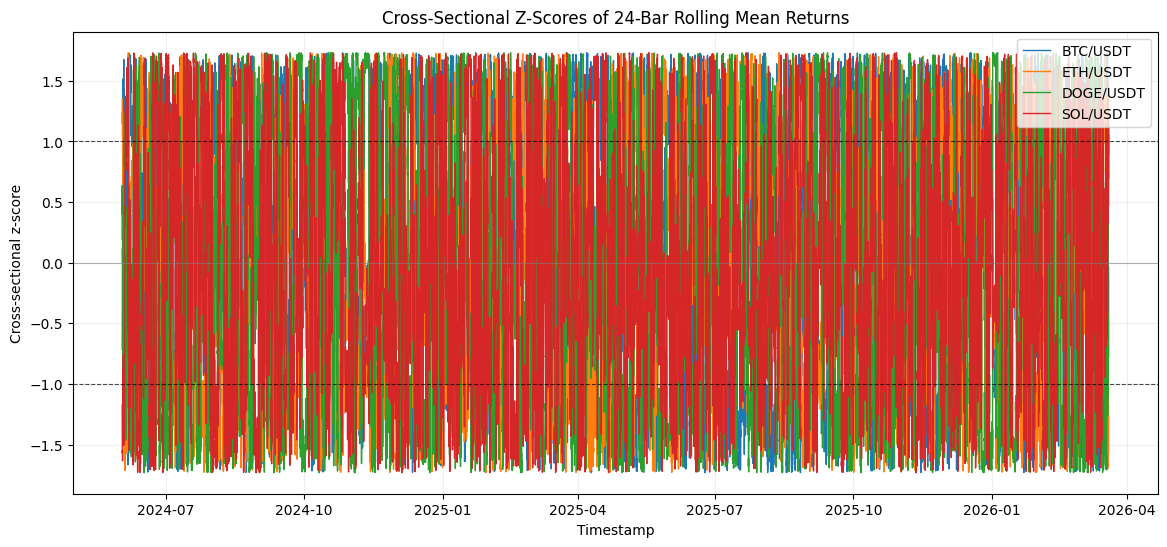

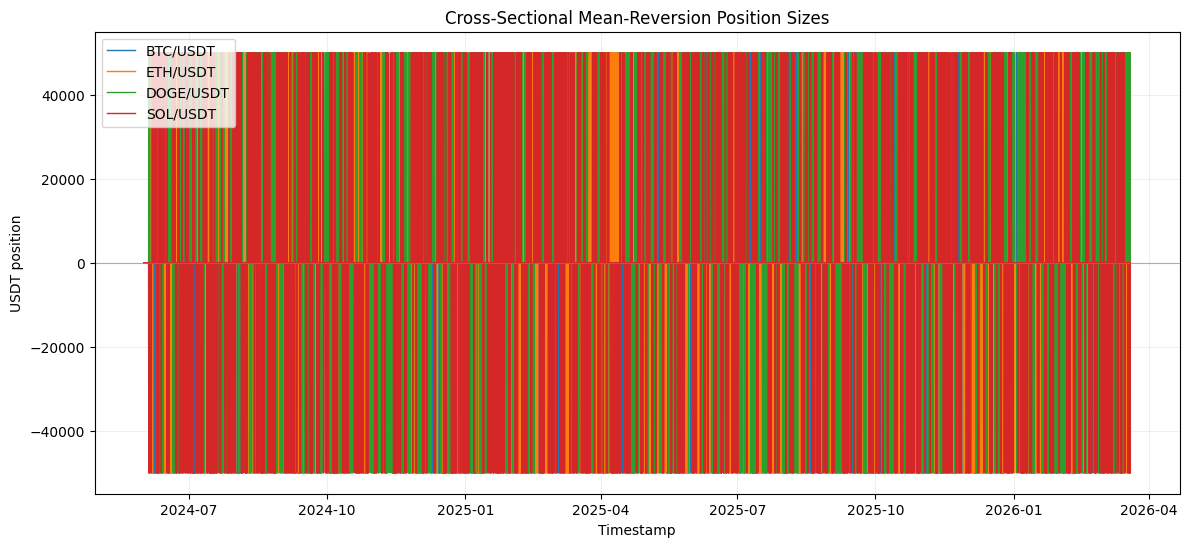

In [93]:
fig, ax = plt.subplots(figsize=(14, 6))
for symbol in ASSET_COLUMNS:
    ax.plot(zscore_df.index, zscore_df[symbol], lw=1.0, label=symbol)
ax.axhline(1.0, color="black", lw=0.8, ls="--", alpha=0.7)
ax.axhline(-1.0, color="black", lw=0.8, ls="--", alpha=0.7)
ax.axhline(0.0, color="grey", lw=0.8, alpha=0.6)
ax.set_title("Cross-Sectional Z-Scores of 24-Bar Rolling Mean Returns")
ax.set_ylabel("Cross-sectional z-score")
ax.set_xlabel("Timestamp")
ax.grid(alpha=0.2)
ax.legend(loc="best")
plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
for symbol in ASSET_COLUMNS:
    ax.plot(theta_df.index, theta_df[symbol], lw=1.0, label=symbol)
ax.axhline(0.0, color="grey", lw=0.8, alpha=0.6)
ax.set_title("Cross-Sectional Mean-Reversion Position Sizes")
ax.set_ylabel("USDT position")
ax.set_xlabel("Timestamp")
ax.grid(alpha=0.2)
ax.legend(loc="best")
plt.show()


For convenience, the final objects from this section are `close_df`, `return_df`, `rolling_mean_return_df`, `zscore_df`, `signal_df`, `position_weight_df`, and `theta_df`.

In [94]:
display(signal_df.tail())
display(theta_df.tail())


,BTC/USDT,ETH/USDT,DOGE/USDT,SOL/USDT
timestamp,,,,
2026-03-19 13:00:00+00:00,0.0,0.5,0.0,-0.5
2026-03-19 14:00:00+00:00,0.0,0.5,0.0,-0.5
2026-03-19 15:00:00+00:00,0.0,0.5,0.0,-0.5
2026-03-19 16:00:00+00:00,0.0,0.5,-0.5,0.0
2026-03-19 17:00:00+00:00,0.0,0.5,0.0,-0.5


,BTC/USDT,ETH/USDT,DOGE/USDT,SOL/USDT
timestamp,,,,
2026-03-19 13:00:00+00:00,0.0,50000.0,0.0,-50000.0
2026-03-19 14:00:00+00:00,0.0,50000.0,0.0,-50000.0
2026-03-19 15:00:00+00:00,0.0,50000.0,0.0,-50000.0
2026-03-19 16:00:00+00:00,0.0,50000.0,-50000.0,0.0
2026-03-19 17:00:00+00:00,0.0,50000.0,0.0,-50000.0


The implementation is fully lagged: z-score thresholds are applied to `zscore_df.shift(1)`, and inverse-volatility sizing uses `vol_df.shift(1)`, so no current-bar information is used to form current-bar positions.

In [95]:
print(f"Starting capital (reference): {INITIAL_CAPITAL_USDT:,.0f} USDT")
print(f"Maximum gross exposure: {GROSS_EXPOSURE_CAP_USDT:,.0f} USDT")
print(f"Maximum observed gross exposure: {gross_exposure_series.max():,.0f} USDT")


Starting capital (reference): 10,000 USDT
Maximum gross exposure: 100,000 USDT
Maximum observed gross exposure: 100,000 USDT


### Trading Results

The trading results below convert the lagged USDT notionals in `theta_df` into per-bar PnL using the close-to-close asset returns in `return_df`. Because the positions are already formed from lagged z-scores and lagged volatilities, this PnL calculation stays forward-looking safe.

In [96]:
asset_pnl_df = theta_df.mul(return_df).fillna(0.0)
portfolio_pnl_series = asset_pnl_df.sum(axis=1)
portfolio_return_series = portfolio_pnl_series / INITIAL_CAPITAL_USDT
equity_curve_series = INITIAL_CAPITAL_USDT + portfolio_pnl_series.cumsum()
drawdown_series = equity_curve_series / equity_curve_series.cummax() - 1.0

active_mask = gross_exposure_series > 0
active_pnl_series = portfolio_pnl_series[active_mask]
position_change_count = int(position_weight_df.ne(position_weight_df.shift(1)).any(axis=1).sum())

annualized_return = portfolio_return_series.mean() * HOURS_PER_YEAR
annualized_vol = portfolio_return_series.std(ddof=0) * np.sqrt(HOURS_PER_YEAR)
sharpe_ratio = annualized_return / annualized_vol if annualized_vol > 0 else np.nan

results_summary = pd.DataFrame(
    {
        "metric": [
            "Ending equity (USDT)",
            "Total PnL (USDT)",
            "Total return (%)",
            "Annualized return (%)",
            "Annualized volatility (%)",
            "Sharpe ratio",
            "Max drawdown (%)",
            "Active-bar win rate (%)",
            "Average gross exposure (USDT)",
            "Position changes",
        ],
        "value": [
            equity_curve_series.iloc[-1],
            portfolio_pnl_series.sum(),
            100.0 * (equity_curve_series.iloc[-1] / INITIAL_CAPITAL_USDT - 1.0),
            100.0 * annualized_return,
            100.0 * annualized_vol,
            sharpe_ratio,
            100.0 * drawdown_series.min(),
            100.0 * (active_pnl_series.gt(0).mean() if not active_pnl_series.empty else np.nan),
            gross_exposure_series[active_mask].mean() if active_mask.any() else 0.0,
            position_change_count,
        ],
    }
)

display(results_summary)
display(pd.DataFrame({"portfolio_pnl_usdt": portfolio_pnl_series, "equity_curve_usdt": equity_curve_series, "drawdown": drawdown_series}).tail())


,metric,value
0,Ending equity (USDT),13430.313576
1,Total PnL (USDT),3430.313576
2,Total return (%),34.303136
3,Annualized return (%),19.064552
4,Annualized volatility (%),254.833217
5,Sharpe ratio,0.074812
6,Max drawdown (%),-317.541693
7,Active-bar win rate (%),52.482674
8,Average gross exposure (USDT),100000.000000
9,Position changes,5961.000000


,portfolio_pnl_usdt,equity_curve_usdt,drawdown
timestamp,,,
2026-03-19 13:00:00+00:00,-114.489784,13124.672486,-0.338650
2026-03-19 14:00:00+00:00,-206.021502,12918.650984,-0.349032
2026-03-19 15:00:00+00:00,272.385320,13191.036303,-0.335306
2026-03-19 16:00:00+00:00,165.256762,13356.293065,-0.326979
2026-03-19 17:00:00+00:00,74.020510,13430.313576,-0.323249


The two charts below show the cumulative equity curve and the realized drawdown path for the strategy.

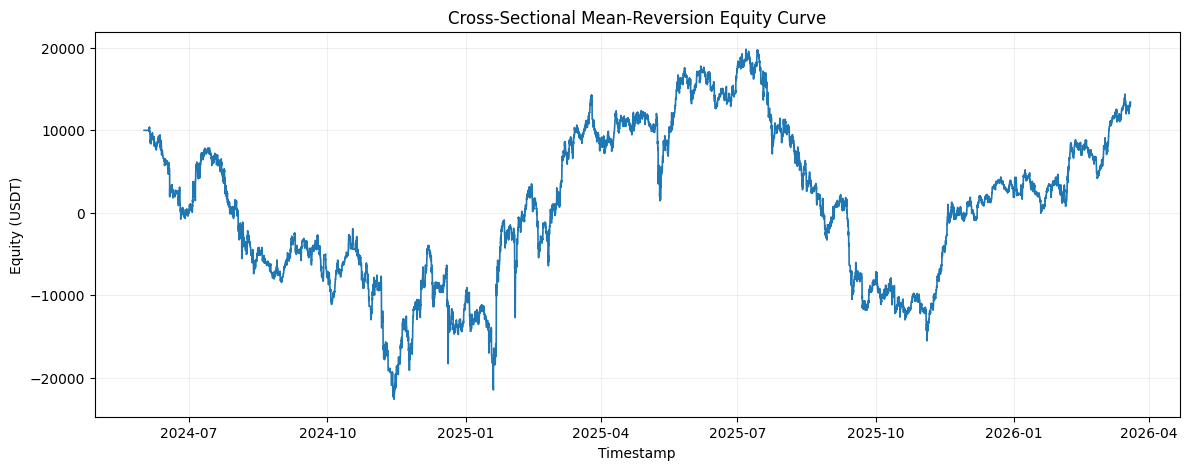

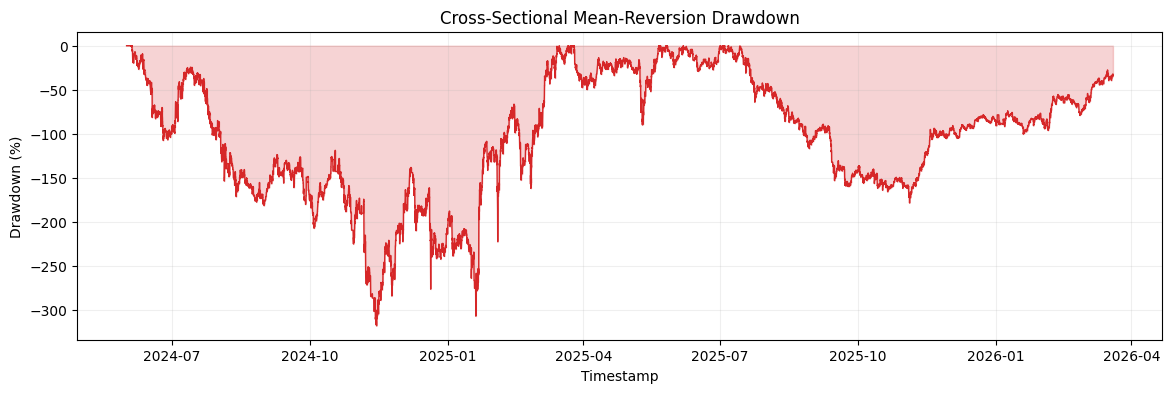

In [97]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(equity_curve_series.index, equity_curve_series, color="tab:blue", lw=1.2)
ax.set_title("Cross-Sectional Mean-Reversion Equity Curve")
ax.set_ylabel("Equity (USDT)")
ax.set_xlabel("Timestamp")
ax.grid(alpha=0.2)
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(drawdown_series.index, 100.0 * drawdown_series, color="tab:red", lw=1.0)
ax.fill_between(drawdown_series.index, 100.0 * drawdown_series, 0.0, color="tab:red", alpha=0.2)
ax.set_title("Cross-Sectional Mean-Reversion Drawdown")
ax.set_ylabel("Drawdown (%)")
ax.set_xlabel("Timestamp")
ax.grid(alpha=0.2)
plt.show()
